In [1]:
from __future__ import division, print_function
import matplotlib.pyplot as plt
import numpy as np
from astropy.table import Table, vstack, hstack
import fitsio
import sys, os, glob, time, warnings, gc
import healpy as hp

from scipy.ndimage.filters import convolve

In [2]:
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'x-large',
         'axes.titlesize':'x-large',
         'xtick.labelsize':'x-large',
         'ytick.labelsize':'x-large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

-------
# Gaussian

In [3]:
gaussian = lambda x, y, a, sigma: a*np.exp(-(x**2+y**2)/(2*sigma**2))
# expontial = lambda x, y, a, b: a*np.exp(-(1/b)*np.sqrt(x**2+y**2))

In [4]:
x = np.linspace(-5, 5, 251)
y = np.linspace(-5, 5, 251)
xx, yy = np.meshgrid(x, y)
rr = np.sqrt(xx**2 + yy**2)

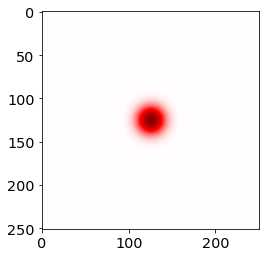

In [5]:
ag = 1.
fwhm = 1.
sigma = fwhm / 2.3548

gg = gaussian(xx, yy, ag, sigma)
plt.imshow(gg, vmin=-1, vmax=1, cmap='seismic')
plt.show()

In [6]:
mask = rr<=0.75
print(np.sum(mask))
print(np.sum(gg))
print(np.sum(gg[mask]))
print()
print('fiberflux-to-flux ratio:')
print(np.sum(gg[mask])/np.sum(gg))

1101
708.1933288752411
558.613414686752

fiberflux-to-flux ratio:
0.7887866094050148


-------
# REX

In [7]:
rexmodel = lambda x, y, a, re: a*np.exp(-(1.67835/re)*np.sqrt(x**2+y**2))

In [8]:
x = np.linspace(-5., 5., 251)
y = np.linspace(-5., 5., 251)
xx, yy = np.meshgrid(x, y)
rr = np.sqrt(xx**2 + yy**2)

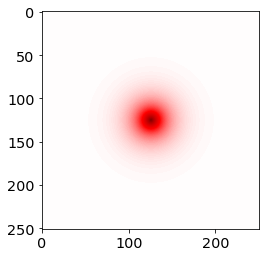

In [9]:
a_rex = 1.
re_rex = 1.

rex2d = rexmodel(xx, yy, a_rex, re_rex)
plt.imshow(rex2d, vmin=-1, vmax=1, cmap='seismic')
plt.show()

In [10]:
# Sanity check the half light radius
mask = rr<=1
print(np.sum(mask))
print(np.sum(rex2d))
print(np.sum(rex2d[mask]))
print()
print('flux within half light radius:')
print(np.sum(rex2d[mask])/np.sum(rex2d))

1957
1392.5762598183608
695.8388040804384

flux within half light radius:
0.4996773420302307


In [11]:
ag = 1.
fwhm = 1.
sigma = fwhm / 2.3548

gg = gaussian(xx, yy, ag, sigma)
rex2d_conv = convolve(rex2d, gg/np.sum(gg), mode='constant')

In [12]:
mask = rr<=0.75
print(np.sum(mask))
print(np.sum(rex2d_conv))
print(np.sum(rex2d_conv[mask]))
print()
print('fiberflux-to-flux ratio:')
print(np.sum(rex2d_conv[mask])/np.sum(rex2d_conv))

1101
1391.896543868551
388.8139841275575

fiberflux-to-flux ratio:
0.27934115207076526


In [13]:
a_rex = 1.
re_rex_arr = np.linspace(0.01, 2, 20)
ratios = np.zeros_like(re_rex_arr)

for index, re_rex in enumerate(re_rex_arr):
    rex2d = rexmodel(xx, yy, a_rex, re_rex)
    rex2d_conv = convolve(rex2d, gg/np.sum(gg), mode='constant')
    mask = rr<=0.75
    ratios[index] = np.sum(rex2d_conv[mask])/np.sum(rex2d_conv)

(0.0, 2.0, 0.1, 0.8)

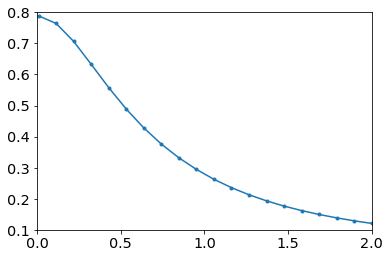

In [14]:
plt.plot(re_rex_arr, ratios, '.-')
plt.axis([0, 2., 0.1, 0.8])

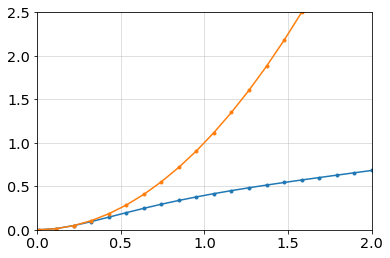

In [15]:
plt.plot(re_rex_arr, re_rex_arr**2 * ratios/ratios[2], '.-')
plt.plot(re_rex_arr, re_rex_arr**2, '.-')
plt.axis([0, 2., 0., 2.5])
plt.grid(alpha=0.5)
plt.show()

x-axis: half light radius (arcsec)  
y-axis: (fiber-)flux

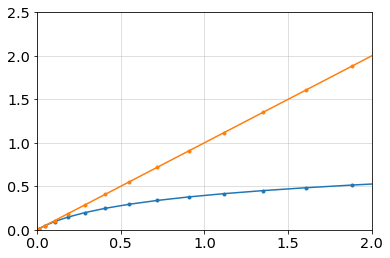

In [16]:
plt.plot(re_rex_arr**2, re_rex_arr**2 * ratios/ratios[2], '.-')
plt.plot(re_rex_arr**2, re_rex_arr**2, '.-')
plt.axis([0, 2., 0., 2.5])
plt.grid(alpha=0.5)
plt.show()

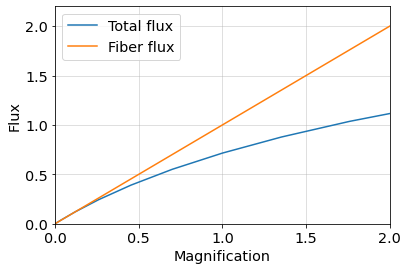

In [44]:
plt.plot(re_rex_arr**2/(re_rex_arr[6]**2), re_rex_arr**2/(re_rex_arr[6]**2) * ratios/ratios[2], '-', label='Total flux')
plt.plot(re_rex_arr**2/(re_rex_arr[6]**2), re_rex_arr**2/(re_rex_arr[6]**2), '-', label='Fiber flux')
plt.axis([0, 2., 0., 2.2])
plt.xlabel('Magnification')
plt.ylabel('Flux')
plt.grid(alpha=0.5)
plt.legend()
plt.show()

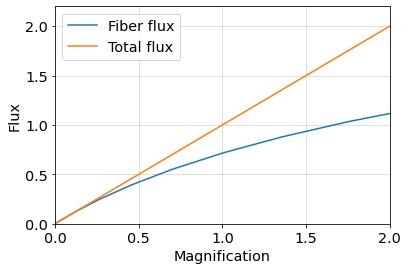

In [46]:
plt.plot(re_rex_arr**2/(re_rex_arr[6]**2), re_rex_arr**2/(re_rex_arr[6]**2) * ratios/ratios[2], '-', label='Fiber flux')
plt.plot(re_rex_arr**2/(re_rex_arr[6]**2), re_rex_arr**2/(re_rex_arr[6]**2), '-', label='Total flux')
plt.axis([0, 2., 0., 2.2])
plt.xlabel('Magnification')
plt.ylabel('Flux')
plt.grid(alpha=0.5)
plt.legend()
plt.show()

In [31]:
a_rex = 1.
re_rex_arr = np.linspace(0.01, 0.7, 10)
ratios = np.zeros_like(re_rex_arr)

for index, re_rex in enumerate(re_rex_arr):
    rex2d = rexmodel(xx, yy, a_rex, re_rex)
    rex2d_conv = convolve(rex2d, gg/np.sum(gg), mode='constant')
    mask = rr<=0.75
    ratios[index] = np.sum(rex2d_conv[mask])/np.sum(rex2d_conv)

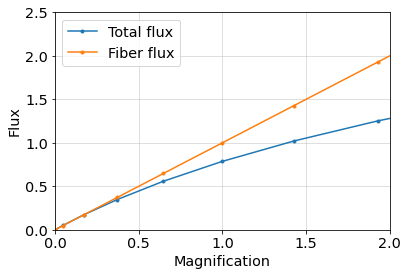

In [32]:
plt.plot(re_rex_arr**2/(re_rex_arr[5]**2), re_rex_arr**2/(re_rex_arr[5]**2) * ratios/ratios[2], '.-', label='Total flux')
plt.plot(re_rex_arr**2/(re_rex_arr[5]**2), re_rex_arr**2/(re_rex_arr[5]**2), '.-', label='Fiber flux')
plt.axis([0, 2., 0., 2.5])
plt.xlabel('Magnification')
plt.ylabel('Flux')
plt.grid(alpha=0.5)
plt.legend()
plt.show()

x-axis: total flux (a.u.)
y-axis: (fiber-)flux

-------
# De Vaucouleurs

In [3]:
devmodel = lambda x, y, a, re: a*np.exp(-7.669*((np.sqrt(x**2+y**2)/re)**(1/4))-1)

In [12]:
x

array([-40.   , -39.984, -39.968, ...,  39.968,  39.984,  40.   ])

In [31]:
x = np.linspace(-20., 20., 4000)
y = np.linspace(-20., 20., 4000)
xx, yy = np.meshgrid(x, y)
rr = np.sqrt(xx**2 + yy**2)

In [35]:
x = np.linspace(-40., 40., 8000)
y = np.linspace(-40., 40., 8000)
xx, yy = np.meshgrid(x, y)
rr = np.sqrt(xx**2 + yy**2)

In [37]:
a_dev = 400.
re_dev = 1.

dev2d = devmodel(xx, yy, a_dev, re_dev)
# plt.imshow(dev2d, vmin=-1, vmax=1, cmap='seismic')
# plt.show()

In [33]:
# Sanity check the half light radius
mask = rr<=re_dev
print(np.sum(mask))
print(np.sum(dev2d))
print(np.sum(dev2d[mask]))
print()
print('flux within half light radius:')
print(np.sum(dev2d[mask])/np.sum(dev2d))

31412
15460.251468039447
7781.6015297374

flux within half light radius:
0.5033295574670367


In [38]:
# Sanity check the half light radius
mask = rr<=re_dev
print(np.sum(mask))
print(np.sum(dev2d))
print(np.sum(dev2d[mask]))
print()
print('flux within half light radius:')
print(np.sum(dev2d[mask])/np.sum(dev2d))

31420
15556.319456423764
7783.5585719413675

flux within half light radius:
0.5003470514824929


In [39]:
mask = rr>10
print(np.sum(dev2d[mask])/np.sum(dev2d))

0.037649831421680616


In [9]:
# Sanity check the half light radius
mask = rr<=re_dev
print(np.sum(mask))
print(np.sum(dev2d))
print(np.sum(dev2d[mask]))
print()
print('flux within half light radius:')
print(np.sum(dev2d[mask])/np.sum(dev2d))

49065
24294.128455934322
12287.451380937375

flux within half light radius:
0.5057786453720641


In [11]:
# Sanity check the half light radius
mask = rr<=re_dev
print(np.sum(mask))
print(np.sum(dev2d))
print(np.sum(dev2d[mask]))
print()
print('flux within half light radius:')
print(np.sum(dev2d[mask])/np.sum(dev2d))

12281
24294.128455934322
7905.085327182889

flux within half light radius:
0.3253907766858751


In [ ]:
ag = 1.
fwhm = 1.
sigma = fwhm / 2.3548

gg = gaussian(xx, yy, ag, sigma)
dev2d_conv = convolve(dev2d, gg/np.sum(gg), mode='constant')

In [29]:
mask = rr<=0.75
print(np.sum(mask))
print(np.sum(dev2d_conv))
print(np.sum(dev2d_conv[mask]))
print()
print('fiberflux-to-flux ratio:')
print(np.sum(dev2d_conv[mask])/np.sum(dev2d_conv))

1101
1006.6041454890843
413.87176218547546

fiberflux-to-flux ratio:
0.4111564253337992
